# RAG using LangGraph


In [3]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain.tools import tool
from typing import TypedDict,List,Annotated
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.graph.message import BaseMessage,add_messages
from langchain.messages import HumanMessage,SystemMessage
# from langchain.checkpoint.mogodb import MongoDBSaver
import os

In [4]:
load_dotenv()

True

In [5]:
os.environ["LANGSMITH_PROJECT"]="RAG_USING_LANGGRAPH_and_LANGCHAIN"

In [6]:
loader=PyPDFLoader("data\\Hands-On-Machine-Learning-with-Scikit-Learn-Keras-and-TensorFlow.pdf")
docs=loader.load()

In [7]:
print(len(docs))

1351


In [8]:
splitter=RecursiveCharacterTextSplitter(chunk_overlap=100,chunk_size=800)


In [9]:
chunks=splitter.split_documents(docs)

In [10]:
embeddings=HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2439.46it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
persist_dir = "./chroma_db"

if os.path.exists(persist_dir):
    print("✅ Loading existing embeddings...")
    
    vector_store = Chroma(
        persist_directory=persist_dir,
        embedding_function=embeddings
    )
else:
    print("🚀 Creating new embeddings (first time only)...")
    
    vector_store = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        persist_directory=persist_dir
    )
    


✅ Loading existing embeddings...


In [13]:
# vector_store=Chroma.from_documents(
#     documents=chunks,
#     embedding=embeddings
# )

In [14]:
vector_store

In [15]:
retriever=vector_store.as_retriever(search_type="similarity",search_kwargs={'k':5})

## youtube video transcribber tool


In [38]:
# from langchain_community.document_loaders import YoutubeLoader

In [39]:
# loader=YoutubeLoader.from_youtube_url("https://youtu.be/O_ewDn_vVz8?si=W2VQbO-Sr-zITofm",add_video_info=False,language=["en","en-us","en-GB"])
# docs=loader.load()
# print(docs)

In [40]:
# @tool
# def youtube_transcriptor_node(url):
#     loader=YoutubeLoader.from_youtube_url(url)
#     docs=loader.load()
    
#     print(docs)

In [41]:
tools=[rag_tool]

In [44]:
retriever.invoke("what is Decision Tree?")[1].page_content

'Figure 6-2. \nDecision tree decision boundaries\nTIP\nThe tree structure, including all the information shown in \nFigure 6-1\n, is available via the\nclassifier’s \ntree_\n attribute. Type \nhelp(tree_clf.tree_)\n for details, and see the \nthis chapter’s\nnotebook\n for an example.\nMODEL INTERPRETATION: WHITE BOX VERSUS BLACK\nBOX\nDecision trees are intuitive, and their decisions are easy to interpret. Such\nmodels are often called \nwhite box models\n. \nIn contrast, as you will see,\nrandom forests and neural networks are generally considered \nblack box\nmodels\n. They make great predictions, and you can easily check the\ncalculations that they performed to make these predictions; nevertheless,\nit is usually hard to explain in simple terms why the predictions were'

In [45]:
len(retriever.invoke("what is Decision Tree?"))  #because we defined kwargs={'k':5}

5

In [46]:
llm=ChatGroq(
    model="llama-3.1-8b-instant"
)

In [47]:
llm_with_tool=llm.bind_tools(tools)

In [ ]:
from pydantic import BaseModel

In [64]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]
    # query:str

In [65]:
class RagInput(BaseModel):
    query:str

In [66]:


@tool(args_schema=RagInput)
def rag_tool(query):
    """
    Use this tool ONLY when the question is related to the provided PDF document.
    
    Input:
    - query: user's question
    
    Output:
    - relevant context from the PDF
    
    If the answer is not in the PDF, do NOT call this tool
    """
    result=retriever.invoke(query)
    
    context= [docs.page_content for docs in result]
    metadata= [docs.metadata for docs in result]
    
    return {
        'query':query,
        'context':context,
        'metadata':metadata
    }

In [67]:
tool_node=ToolNode(tools)

In [59]:
# def chat_node(state:ChatState):
#     message=state["messages"]
#     response=llm_with_tool.invoke(message)
#     return {"messages":[response]}

In [71]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt

# def human_review_node(state: ChatState):
#     user_input = state['messages'][-1].content
#     confirm = interrupt(f"Are you sure you want to ask '{user_input}'? (Y/N):")
#     if confirm.strip().lower() != 'y':
#         return {"messages": [HumanMessage(content="__CANCELLED__")]}
#     return state


def human_review_node(state: ChatState):
    user_input = state["messages"][-1].content

    confirm = interrupt(f"Are you sure you want to ask '{user_input}'? (Y/N):")

    if confirm.strip().lower() != "y":
        return {"messages": [HumanMessage(content="__CANCELLED__")]}

    return state

# def chat_node(state: ChatState):
#     if state['messages'][-1].content == '__CANCELLED__':
#         return {"messages": [HumanMessage(content="Request cancelled by user.")]}
#     return {"messages": [llm_with_tool.invoke(state['messages'])]}


def chat_node(state: ChatState):
    messages = state["messages"]

    try:
        system_message="think of you as a helpful assistant and answer my query"
        response = llm_with_tool.invoke([system_message]+messages)
        return {"messages": [response]}

    except Exception as e:
        return {
            "messages": [
                HumanMessage(content=f"Error: {str(e)}")
            ]
        }


checkpointer = MemorySaver()

graph = StateGraph(ChatState)
graph.add_node('human_review', human_review_node)
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'human_review')
graph.add_edge('human_review', 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

workflow = graph.compile(checkpointer=checkpointer)


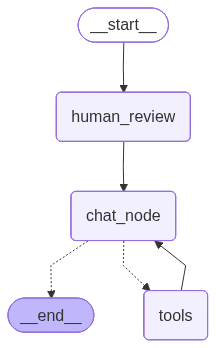

In [72]:
workflow

In [73]:
from langgraph.types import Command

config = {"configurable": {"thread_id": "1"}}
user_input = input("Ask a question: ")

# Step 1: Run until interrupt
result = workflow.invoke({"messages": [HumanMessage(content=user_input)]}, config=config)

# Step 2: Get human confirmation and resume
confirm = input(result['__interrupt__'][0].value + " ").strip().lower()
final = workflow.invoke(Command(resume=confirm), config=config)
print(final['messages'][-1].content)

A decision tree is a machine learning algorithm that can perform both classification and regression tasks. It is a versatile algorithm that can fit complex datasets and is capable of making predictions by asking a series of questions. The decision tree algorithm works by creating a tree-like model of decisions and their possible consequences, including chance event outcomes, resource costs, and utility. It is a powerful algorithm that can be used for a wide range of tasks, including classification, regression, and multioutput tasks.

The decision tree algorithm works by recursively partitioning the data into smaller subsets based on the values of the input features. Each node in the tree represents a decision, and the branches represent the possible outcomes of that decision. The leaf nodes represent the final predictions or classifications.

Decision trees are also the fundamental components of random forests, which are among the most powerful machine learning algorithms available tod

In [74]:
# print(response["messages"][-1].content)